# Analyse professionnelle du risque d'inondation

Ce carnet couvre l'ensemble du pipeline : nettoyage des données météo, agrégation, création d'une cible proxy et entraînement d'un modèle de classification.

## Plan
1. Imports & configuration
2. Chargement et contrôle qualité des observations horaires
3. Agrégation journalière et exploration
4. Construction de la cible proxy
5. Préparation des matrices & entraînement
6. Évaluation complète (métriques, courbes, importance, erreurs)
7. Sauvegarde, résumé et fonction de prédiction

In [23]:
from __future__ import annotations

import json
import math
from pathlib import Path
from typing import Dict, Iterable, List, Tuple

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

SEUIL_OPTIMAL=0.35

plt.style.use('seaborn-v0_8')
sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'axes.titleweight': 'semibold',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.titlesize': 16,
    'legend.fontsize': 11,
})

DATA_DIR = Path('/Users/mac/Documents/Innond/flood_api/donnees').resolve()
MODELS_DIR = Path('/Users/mac/Documents/Innond/flood_api/models').resolve()
print(f'Repertoire donnees: {DATA_DIR}')


Repertoire donnees: /Users/mac/Documents/Innond/flood_api/donnees


## 1. Fonctions utilitaires

In [24]:
RAINY_MONTHS = {6, 7, 8, 9, 10}

SUBSTITUTIONS = {
    " ": "_",
    "/": "_per_",
    "%": "pct",
    "°": "deg",
    "²": "2",
    "³": "3",
    "(": "",
    ")": "",
    "-": "_",
}

AGGREGATION_MAP = {
    "precipitation_mm": ("sum", "max"),
    "rain_mm": ("sum", "max"),
    "relative_humidity_2m_pct": ("mean", "min", "max"),
    "temperature_2m_degc": ("mean", "min", "max"),
    "dew_point_2m_degc": ("mean",),
    "vapour_pressure_deficit_kpa": ("mean", "max"),
    "pressure_msl_hpa": ("mean",),
    "surface_pressure_hpa": ("mean",),
    "wind_speed_10m_km_per_h": ("mean",),
    "wind_speed_100m_km_per_h": ("mean",),
    "wind_gusts_10m_km_per_h": ("mean", "max"),
    "soil_moisture_0_to_7cm_m3_per_m3": ("mean", "max"),
    "soil_moisture_7_to_28cm_m3_per_m3": ("mean",),
    "soil_moisture_28_to_100cm_m3_per_m3": ("mean",),
    "soil_moisture_100_to_255cm_m3_per_m3": ("mean",),
    "soil_temperature_0_to_7cm_degc": ("mean",),
    "soil_temperature_7_to_28cm_degc": ("mean",),
    "soil_temperature_28_to_100cm_degc": ("mean",),
    "soil_temperature_100_to_255cm_degc": ("mean",),
    "cloud_cover_pct": ("mean",),
    "cloud_cover_low_pct": ("mean",),
    "cloud_cover_mid_pct": ("mean",),
    "cloud_cover_high_pct": ("mean",),
    "et0_fao_evapotranspiration_mm": ("sum",),
    "shortwave_radiation_w_per_m2": ("sum", "mean"),
}

GEO_COLUMNS = ("latitude", "longitude", "elevation", "utc_offset_seconds", "region")


def normalise_column(label: str) -> str:
    label = label.strip().lower()
    for src, dst in SUBSTITUTIONS.items():
        label = label.replace(src, dst)
    while "__" in label:
        label = label.replace("__", "_")
    return label.strip("_")


def extract_metadata(path: Path) -> Dict[str, str]:
    head = pd.read_csv(path, nrows=1, encoding="utf-8")
    if head.empty:
        return {}
    return {normalise_column(k): v for k, v in head.iloc[0].to_dict().items()}


def coerce_float(value: object) -> float:
    try:
        return float(value)
    except (TypeError, ValueError):
        return math.nan


def location_from_path(path: Path) -> str:
    parts = path.stem.split("_")
    if len(parts) >= 3 and all(p.isdigit() for p in parts[-2:]):
        return "_".join(parts[:-2])
    return path.stem


def load_hourly_data(data_dir: Path) -> pd.DataFrame:
    frames = []
    for csv_path in sorted(data_dir.glob("*.csv")):
        metadata = extract_metadata(csv_path)
        frame = pd.read_csv(csv_path, skiprows=3, encoding="utf-8")
        frame.columns = [normalise_column(c) for c in frame.columns]
        if "time" not in frame.columns:
            raise ValueError(f"Colonne 'time' manquante dans {csv_path.name}")
        frame["time"] = pd.to_datetime(frame["time"], errors="coerce")
        frame = frame.dropna(subset=["time"])
        numeric_cols = [c for c in frame.columns if c != "time"]
        frame[numeric_cols] = frame[numeric_cols].apply(pd.to_numeric, errors="coerce")
        location = location_from_path(csv_path)
        frame["location"] = location
        frame["region"] = metadata.get("region") or metadata.get("departement") or metadata.get("department") or metadata.get("commune") or np.nan
        for geo_col in ("latitude", "longitude", "elevation", "utc_offset_seconds"):
            frame[geo_col] = coerce_float(metadata.get(geo_col))
        frames.append(frame)
    if not frames:
        raise FileNotFoundError("Aucun CSV trouvé.")
    data = pd.concat(frames, ignore_index=True)
    return data.sort_values(["location", "time"])


def flatten_columns(columns: pd.MultiIndex) -> List[str]:
    flattened = []
    for base, stat in columns:
        if not stat or stat == "first":
            flattened.append(base)
        else:
            flattened.append(f"{base}_{stat}")
    return flattened


def aggregate_daily(hourly: pd.DataFrame) -> pd.DataFrame:
    df = hourly.copy()
    df["date"] = df["time"].dt.floor("D")
    agg_dict: Dict[str, List[str]] = {}
    for feature, stats in AGGREGATION_MAP.items():
        if feature in df.columns:
            agg_dict[feature] = list(stats)
    base_aggs = {col: "first" for col in GEO_COLUMNS if col in df.columns}
    grouped = df.groupby(["location", "date"]).agg({**base_aggs, **agg_dict}).dropna(how="all")
    grouped.columns = flatten_columns(grouped.columns)
    # Pandas 3.0 fix: drop columns that duplicate index names before reset_index
    for idx_name in grouped.index.names:
        if idx_name in grouped.columns:
            grouped = grouped.drop(columns=[idx_name])
    return grouped.reset_index()


def seasonal_features(frame: pd.DataFrame) -> pd.DataFrame:
    frame = frame.copy()
    frame["month"] = frame["date"].dt.month
    frame["dayofyear"] = frame["date"].dt.dayofyear
    frame["is_rainy_season"] = frame["month"].isin(RAINY_MONTHS).astype(int)
    frame["dayofyear_sin"] = np.sin(2 * math.pi * frame["dayofyear"] / 365.25)
    frame["dayofyear_cos"] = np.cos(2 * math.pi * frame["dayofyear"] / 365.25)
    return frame


def rolling_features(frame: pd.DataFrame) -> pd.DataFrame:
    frame = frame.sort_values(["location", "date"]).copy()

    def enrich(group: pd.DataFrame) -> pd.DataFrame:
        group = group.sort_values("date")
        precip = group.get("precipitation_mm_sum")
        rain_sum = group.get("rain_mm_sum")
        humidity = group.get("relative_humidity_2m_pct_mean")
        temperature = group.get("temperature_2m_degc_mean")
        soil_top = group.get("soil_moisture_0_to_7cm_m3_per_m3_mean")
        soil_sub = group.get("soil_moisture_7_to_28cm_m3_per_m3_mean")
        if precip is not None:
            group["precip_3d_sum"] = precip.rolling(3, min_periods=1).sum()
            group["precip_7d_sum"] = precip.rolling(7, min_periods=1).sum()
            group["precip_15d_sum"] = precip.rolling(15, min_periods=1).sum()
        if rain_sum is not None:
            group["rain_3d_sum"] = rain_sum.rolling(3, min_periods=1).sum()
        if humidity is not None:
            group["humidity_3d_mean"] = humidity.rolling(3, min_periods=1).mean()
        if temperature is not None:
            group["temp_3d_mean"] = temperature.rolling(3, min_periods=1).mean()
        if soil_top is not None and soil_sub is not None:
            group["soil_moisture_gradient"] = soil_top - soil_sub
        return group

    result = frame.groupby("location", group_keys=False).apply(enrich)
    # Ensure 'location' is a column if it was pushed to the index by pandas 3.0
    if "location" not in result.columns and "location" in result.index.names:
        result = result.reset_index(level="location")
    return result


def build_training_table(hourly: pd.DataFrame) -> pd.DataFrame:
    daily = aggregate_daily(hourly)
    daily = seasonal_features(daily)
    daily = daily[daily['month'].isin(RAINY_MONTHS)]
    daily = rolling_features(daily)
    return daily.dropna(subset=['precipitation_mm_sum'])


SELECTED_FEATURES = [
    "precipitation_mm_sum",
    "precipitation_mm_max",
    "relative_humidity_2m_pct_mean",
    "relative_humidity_2m_pct_max",
    "temperature_2m_degc_mean",
    "temperature_2m_degc_max",
    "precip_3d_sum",
    "precip_7d_sum",
    "precip_15d_sum",
]


## 2. Chargement et aperçu

In [25]:
hourly = load_hourly_data(DATA_DIR)
hourly.head()

,time,temperature_2m_degc,relative_humidity_2m_pct,dew_point_2m_degc,apparent_temperature_degc,precipitation_mm,rain_mm,snowfall_cm,snow_depth_m,weather_code_wmo_code,...,diffuse_radiation_instant_w_per_m2,direct_normal_irradiance_instant_w_per_m2,global_tilted_irradiance_instant_w_per_m2,terrestrial_radiation_instant_w_per_m2,location,region,latitude,longitude,elevation,utc_offset_seconds
0,2005-04-07 00:00:00,26.5,51,15.6,26.3,0.0,0.0,0.0,0.0,1,...,0.0,0.0,0.0,0.0,kaolack_leona,NaN,13.813708,-15.551483,25.0,0.0
1,2005-04-07 01:00:00,25.6,55,15.8,25.5,0.0,0.0,0.0,0.0,1,...,0.0,0.0,0.0,0.0,kaolack_leona,NaN,13.813708,-15.551483,25.0,0.0
2,2005-04-07 02:00:00,24.7,58,15.9,24.9,0.0,0.0,0.0,0.0,1,...,0.0,0.0,0.0,0.0,kaolack_leona,NaN,13.813708,-15.551483,25.0,0.0
3,2005-04-07 03:00:00,24.0,62,16.2,24.7,0.0,0.0,0.0,0.0,1,...,0.0,0.0,0.0,0.0,kaolack_leona,NaN,13.813708,-15.551483,25.0,0.0
4,2005-04-07 04:00:00,23.4,65,16.4,24.6,0.0,0.0,0.0,0.0,0,...,0.0,0.0,0.0,0.0,kaolack_leona,NaN,13.813708,-15.551483,25.0,0.0


In [26]:
summary = hourly.groupby('location')['time'].agg(['min', 'max', 'count'])
summary

,min,max,count
location,,,
kaolack_leona,2005-04-07,2025-07-31 23:00:00,178104
keur_massar,2005-04-07,2025-07-31 23:00:00,178104
kolda,2005-04-07,2025-07-31 23:00:00,178104
matam,2005-04-07,2025-07-31 23:00:00,178104
tambacounda,2005-04-07,2025-07-31 23:00:00,178104
touba,2005-04-07,2025-07-31 23:00:00,178104


In [27]:
summary.assign(duree_jours=(summary['max'] - summary['min']).dt.days).rename(columns={'min': 'debut', 'max': 'fin', 'count': 'nb_observations'})

,debut,fin,nb_observations,duree_jours
location,,,,
kaolack_leona,2005-04-07,2025-07-31 23:00:00,178104,7420
keur_massar,2005-04-07,2025-07-31 23:00:00,178104,7420
kolda,2005-04-07,2025-07-31 23:00:00,178104,7420
matam,2005-04-07,2025-07-31 23:00:00,178104,7420
tambacounda,2005-04-07,2025-07-31 23:00:00,178104,7420
touba,2005-04-07,2025-07-31 23:00:00,178104,7420


## 3. Agrégation et exploration

In [28]:
daily = build_training_table(hourly)
daily.head()

,date,latitude,longitude,elevation,utc_offset_seconds,region,precipitation_mm_sum,precipitation_mm_max,rain_mm_sum,rain_mm_max,...,is_rainy_season,dayofyear_sin,dayofyear_cos,precip_3d_sum,precip_7d_sum,precip_15d_sum,rain_3d_sum,humidity_3d_mean,temp_3d_mean,soil_moisture_gradient
55,2005-06-01,13.813708,-15.551483,25.0,0.0,NaN,0.0,0.0,0.0,0.0,...,1,0.502791,-0.864408,0.0,0.0,0.0,0.0,56.750000,29.845833,-0.028375
56,2005-06-02,13.813708,-15.551483,25.0,0.0,NaN,0.0,0.0,0.0,0.0,...,1,0.487847,-0.872929,0.0,0.0,0.0,0.0,55.270833,29.697917,-0.029000
57,2005-06-03,13.813708,-15.551483,25.0,0.0,NaN,0.0,0.0,0.0,0.0,...,1,0.472759,-0.881192,0.0,0.0,0.0,0.0,54.458333,29.468056,-0.029000
58,2005-06-04,13.813708,-15.551483,25.0,0.0,NaN,1.0,0.6,1.0,0.6,...,1,0.457531,-0.889193,1.0,1.0,1.0,1.0,53.875000,29.308333,-0.017208
59,2005-06-05,13.813708,-15.551483,25.0,0.0,NaN,0.0,0.0,0.0,0.0,...,1,0.442168,-0.896932,1.0,1.0,1.0,1.0,54.291667,29.270833,-0.019042


In [29]:
locations = sorted(daily['location'].unique())
fig, axes = plt.subplots(len(locations), 1, figsize=(15, 2.6 * len(locations)), sharex=True)
if len(locations) == 1:
    axes = [axes]
for ax, location in zip(axes, locations):
    subset = daily[daily['location'] == location].set_index('date')
    series = subset['precipitation_mm_sum']
    ax.plot(series.index, series, alpha=0.25, label='Somme journalier (mm)')
    ax.plot(series.index, series.rolling(7, min_periods=1).mean(), color='tab:blue', label='Moyenne 7j')
    ax.set_ylabel('mm')
    ax.set_title(location)
    ax.legend(loc='upper right')
axes[-1].set_xlabel('date')
plt.tight_layout()
plt.show()

KeyError: 'location'

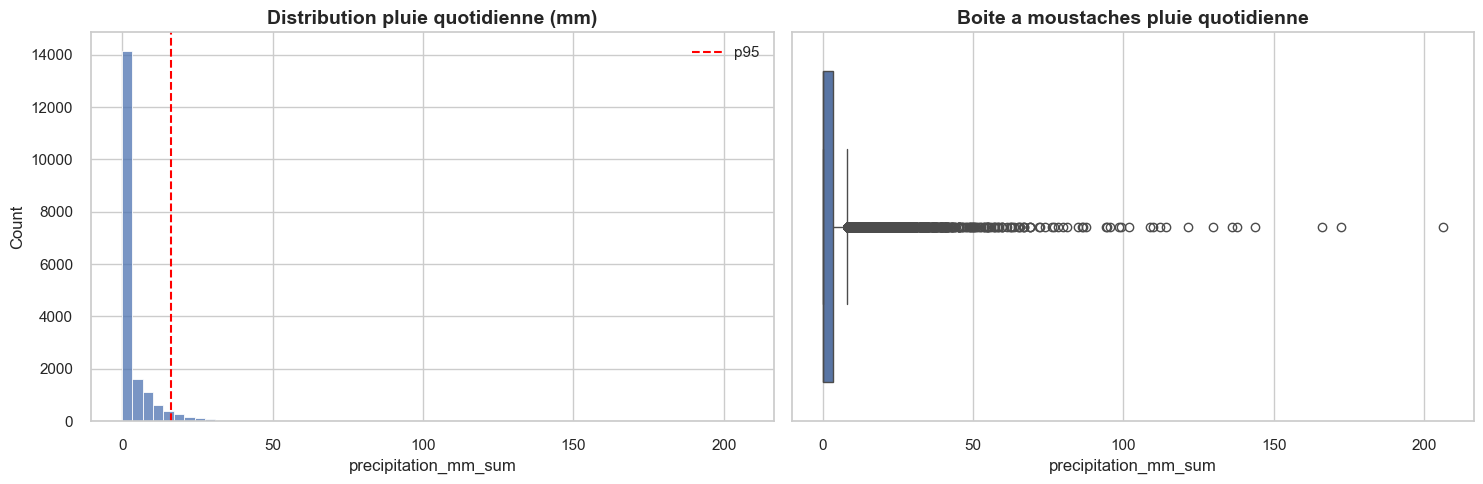

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(daily['precipitation_mm_sum'], bins=60, ax=axes[0])
axes[0].axvline(daily['precipitation_mm_sum'].quantile(0.95), color='red', linestyle='--', label='p95')
axes[0].set_title('Distribution pluie quotidienne (mm)')
axes[0].legend()
sns.boxplot(x=daily['precipitation_mm_sum'], ax=axes[1])
axes[1].set_title('Boite a moustaches pluie quotidienne')
plt.tight_layout()
plt.show()

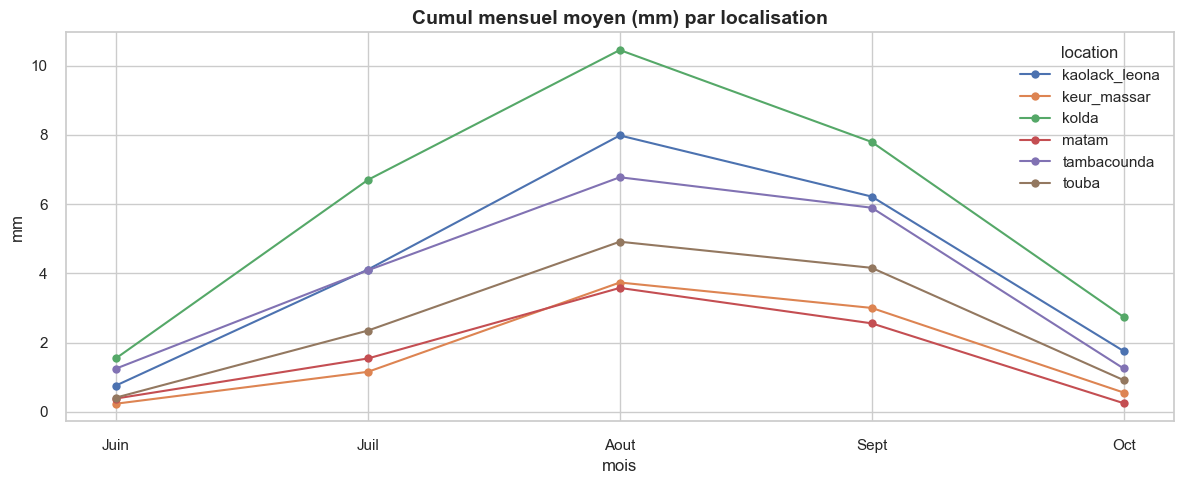

In [ ]:
monthly = (daily.assign(month=daily['date'].dt.month)
           .groupby(['month', 'location'])['precipitation_mm_sum']
           .mean()
           .unstack('location')
           .sort_index())
fig, ax = plt.subplots(figsize=(12, 5))
monthly.plot(ax=ax, marker='o')
ax.set_title('Cumul mensuel moyen (mm) par localisation')
ax.set_ylabel('mm')
ax.set_xlabel('mois')
month_labels = {
    1: 'jan', 2: 'fev', 3: 'mar', 4: 'avr', 5: 'mai',
    6: 'juin', 7: 'juil', 8: 'aout', 9: 'sept', 10: 'oct',
    11: 'nov', 12: 'dec'
}
ax.set_xticks(monthly.index)
ax.set_xticklabels([month_labels.get(m, str(m)).capitalize() for m in monthly.index])
plt.tight_layout()
plt.show()


## 4. Cible proxy

In [ ]:
SPLIT_DATE = pd.Timestamp('2023-01-01')
train = daily[daily['date'] < SPLIT_DATE].copy()
test = daily[daily['date'] >= SPLIT_DATE].copy()

daily_cutoff = float(train['precipitation_mm_sum'].quantile(0.97))
three_day_cutoff = float(train['precip_3d_sum'].quantile(0.95))

for df in (train, test):
    df['flood_risk'] = ((df['precipitation_mm_sum'] >= daily_cutoff) | (df['precip_3d_sum'] >= three_day_cutoff)).astype(int)

{'daily_cutoff_mm': daily_cutoff, 'three_day_cutoff_mm': three_day_cutoff}

{'daily_cutoff_mm': 20.3, 'three_day_cutoff_mm': 39.0}

In [ ]:
pd.DataFrame({'train': train['flood_risk'].value_counts(), 'test': test['flood_risk'].value_counts()}).fillna(0).astype(int)

,train,test
flood_risk,,
0,15494,1999
1,1030,203


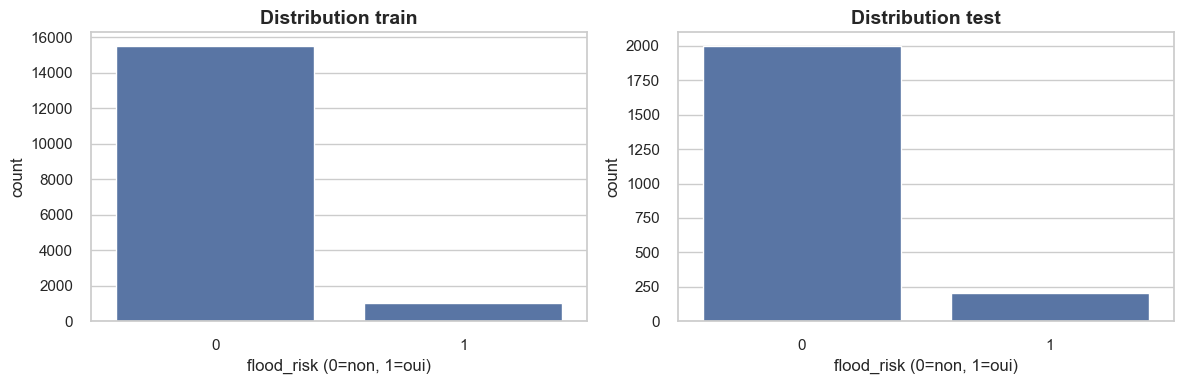

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x='flood_risk', data=train, ax=axes[0])
axes[0].set_title('Distribution train')
sns.countplot(x='flood_risk', data=test, ax=axes[1])
axes[1].set_title('Distribution test')
for ax in axes:
    ax.set_xlabel('flood_risk (0=non, 1=oui)')
plt.tight_layout()
plt.show()

## 5. Matrices d'entraînement

In [ ]:
def prepare_matrix(df: pd.DataFrame, features: List[str]) -> Tuple[np.ndarray, np.ndarray, StandardScaler]:
    X = df[features].ffill().bfill().fillna(0).to_numpy(dtype=float)
    y = df['flood_risk'].to_numpy(dtype=int)
    scaler = StandardScaler().fit(X)
    return scaler.transform(X), y, scaler

train_X, train_y, scaler = prepare_matrix(train, SELECTED_FEATURES)
test_X = scaler.transform(test[SELECTED_FEATURES].ffill().bfill().fillna(0).to_numpy(dtype=float))
test_y = test['flood_risk'].to_numpy(dtype=int)
train_X.shape, test_X.shape

((16524, 9), (2202, 9))

## 6. Entraînement RandomForest

In [ ]:
rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=10,
    min_samples_leaf=5,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1,
)
rf.fit(train_X, train_y)
train_proba = rf.predict_proba(train_X)[:, 1]
test_proba = rf.predict_proba(test_X)[:, 1]
test_pred = (test_proba >= SEUIL_OPTIMAL).astype(int)

## 7. Métriques globales


In [ ]:
metrics = {
    'roc_auc': roc_auc_score(test_y, test_proba),
    'average_precision': average_precision_score(test_y, test_proba),
    'precision': precision_score(test_y, test_pred),
    'recall': recall_score(test_y, test_pred),
    'f1': f1_score(test_y, test_pred),
    'accuracy': accuracy_score(test_y, test_pred),
    'support_positif': int(test_y.sum()),
    'support_total': int(len(test_y)),
}
pd.Series(metrics).to_frame('valeur')

,valeur
roc_auc,1.000000
average_precision,1.000000
precision,0.995098
recall,1.000000
f1,0.997543
accuracy,0.999546
support_positif,203.000000
support_total,2202.000000


## 8. Courbes ROC / PR et matrice


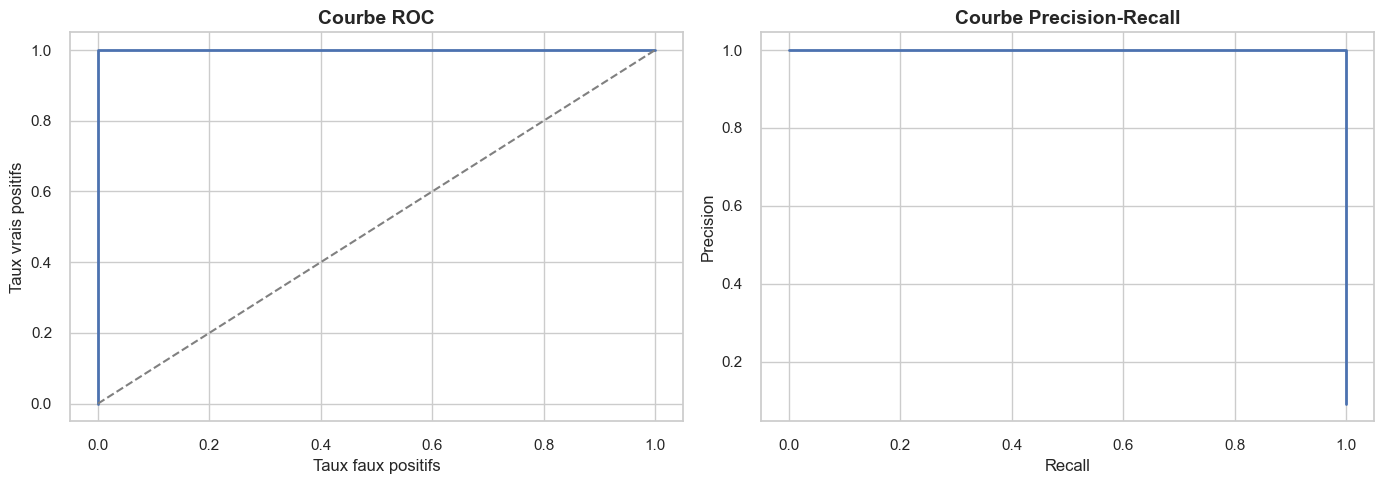

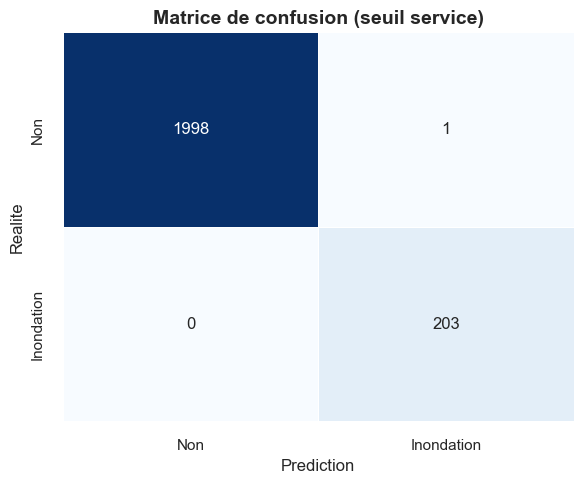

In [ ]:
fpr, tpr, _ = roc_curve(test_y, test_proba)
prec, recall, _ = precision_recall_curve(test_y, test_proba)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(fpr, tpr, linewidth=2)
axes[0].plot([0, 1], [0, 1], linestyle='--', color='grey')
axes[0].set_title('Courbe ROC')
axes[1].plot(recall, prec, linewidth=2)
axes[1].set_title('Courbe Precision-Recall')
axes[0].set_xlabel('Taux faux positifs')
axes[0].set_ylabel('Taux vrais positifs')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
plt.tight_layout()
plt.show()

cm = confusion_matrix(test_y, test_pred)
cm_df = pd.DataFrame(cm, index=['Non', 'Inondation'], columns=['Non', 'Inondation'])
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', linewidths=0.5, linecolor='white', cbar=False, ax=ax)
ax.set_title('Matrice de confusion (seuil service)')
ax.set_xlabel('Prediction')
ax.set_ylabel('Realite')
plt.tight_layout()
plt.show()

## 9. Distribution des probabilités


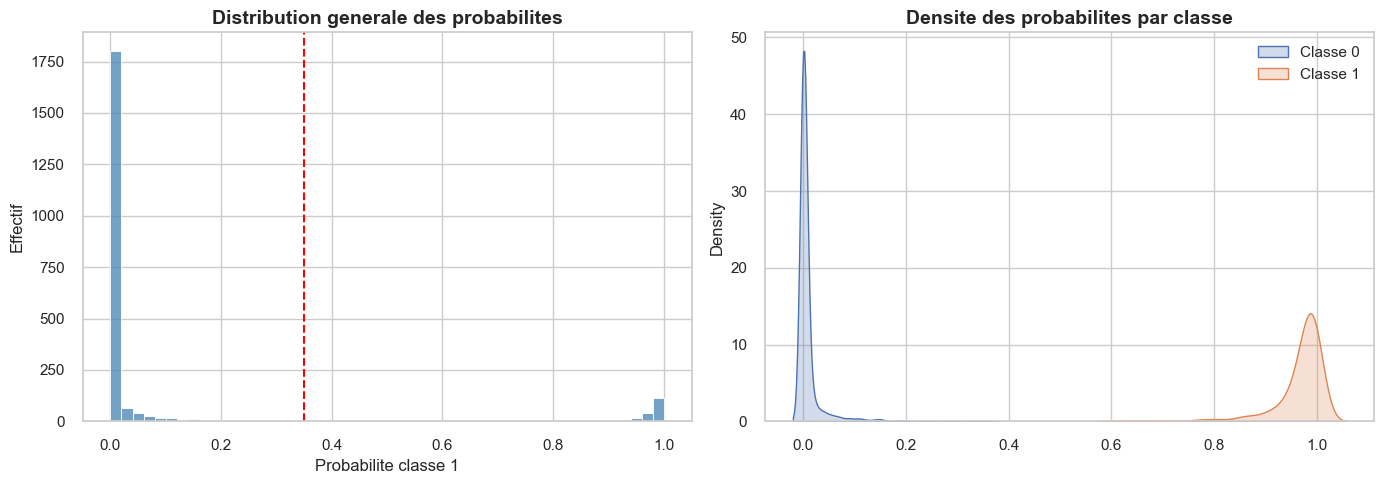

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(test_proba, bins=50, ax=axes[0], color='steelblue')
axes[0].axvline(SEUIL_OPTIMAL, color='red', linestyle='--')
axes[0].set_title('Distribution generale des probabilites')
axes[0].set_xlabel('Probabilite classe 1')
axes[0].set_ylabel('Effectif')

sns.kdeplot(test_proba[test_y == 0], fill=True, label='Classe 0', ax=axes[1])
sns.kdeplot(test_proba[test_y == 1], fill=True, label='Classe 1', ax=axes[1])
axes[1].set_title('Densite des probabilites par classe')
axes[1].legend()
plt.tight_layout()
plt.show()

## 10. Importance des variables


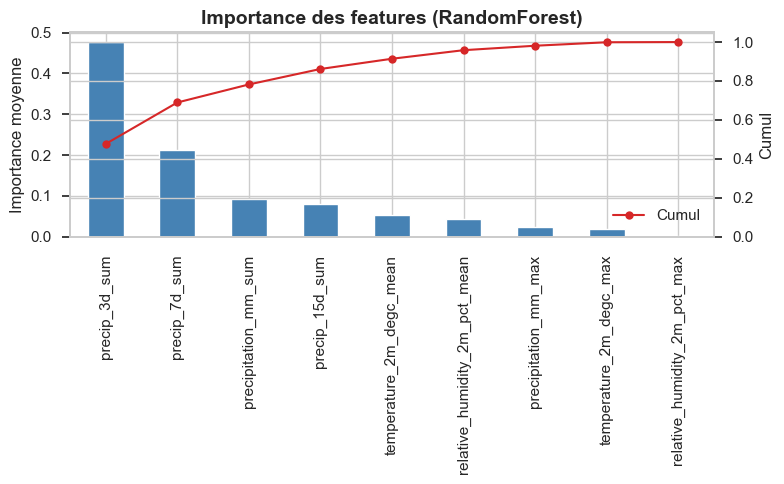

,importance
precip_3d_sum,0.476727
precip_7d_sum,0.212768
precipitation_mm_sum,0.092687
precip_15d_sum,0.079464
temperature_2m_degc_mean,0.052619
relative_humidity_2m_pct_mean,0.043964
precipitation_mm_max,0.022929
temperature_2m_degc_max,0.017873
relative_humidity_2m_pct_max,0.000968


In [ ]:
importance = pd.Series(rf.feature_importances_, index=SELECTED_FEATURES).sort_values(ascending=False)
fig, ax1 = plt.subplots(figsize=(8, 5))
importance.plot.bar(ax=ax1, color='steelblue')
ax1.set_ylabel('Importance moyenne')
ax1.set_title('Importance des features (RandomForest)')
ax2 = ax1.twinx()
ax2.plot(importance.index, importance.cumsum().values, color='tab:red', marker='o', label='Cumul')
ax2.set_ylabel('Cumul')
ax2.set_ylim(0, 1.05)
ax2.legend(loc='lower right')
plt.tight_layout()
plt.show()
importance.to_frame('importance')

## 11. Analyse des erreurs


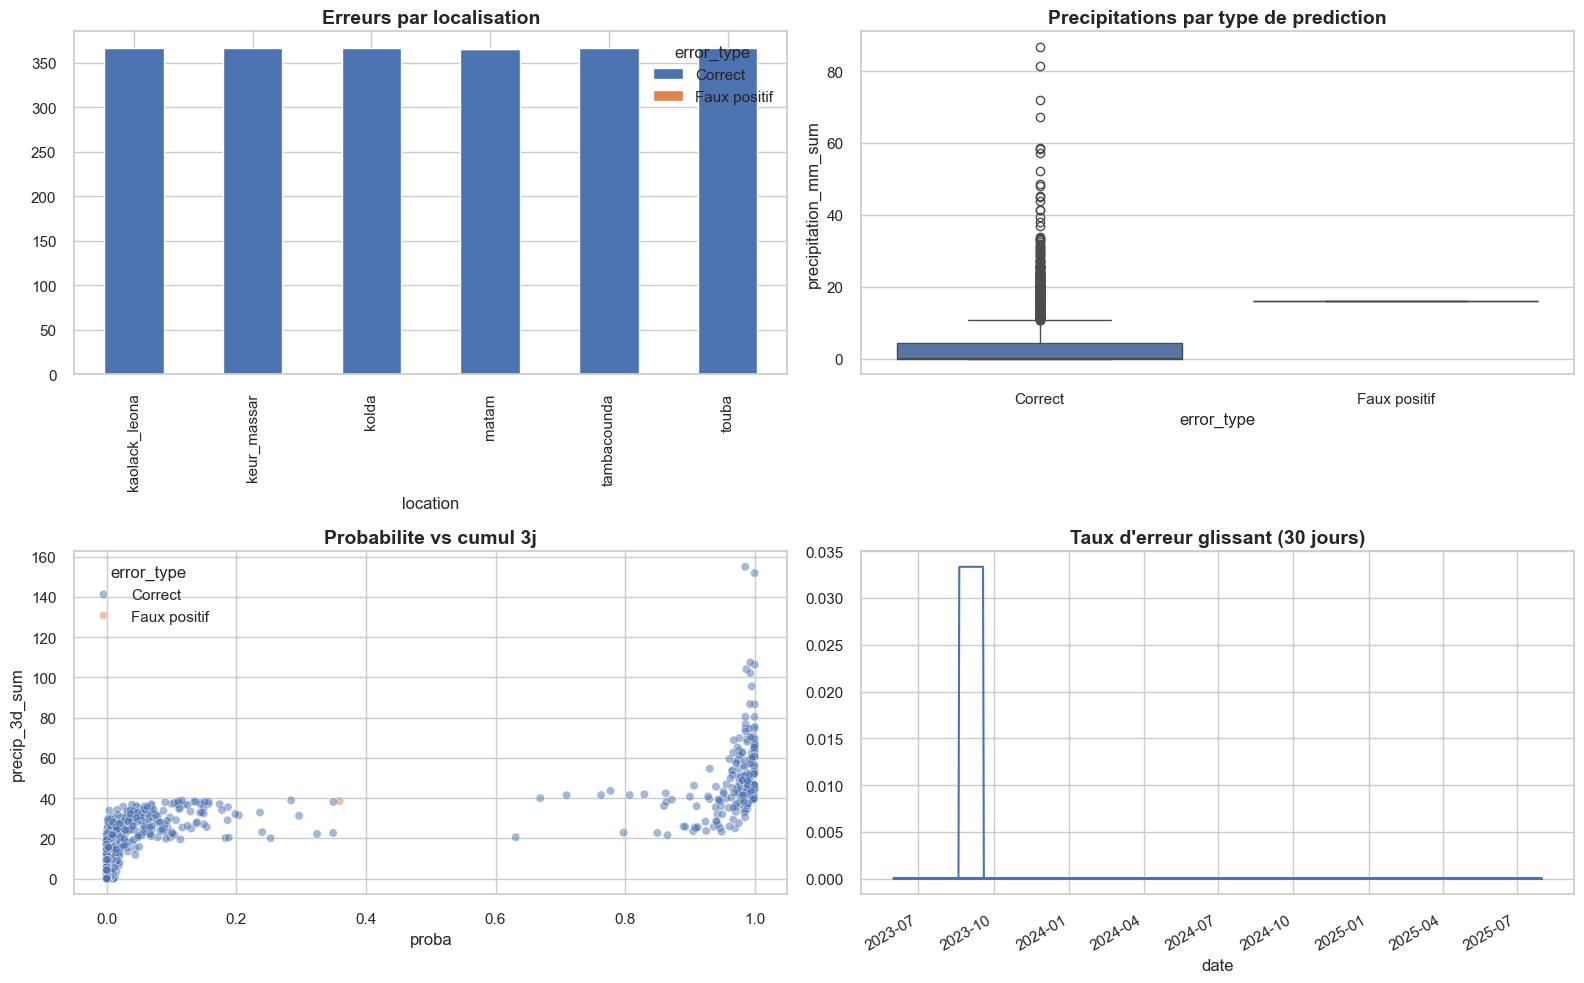

In [ ]:
analysis_df = test.copy()
analysis_df['proba'] = test_proba
analysis_df['pred'] = test_pred
analysis_df['error_type'] = np.select(
    [
        (analysis_df['pred'] == 1) & (analysis_df['flood_risk'] == 0),
        (analysis_df['pred'] == 0) & (analysis_df['flood_risk'] == 1),
    ],
    ['Faux positif', 'Faux negatif'],
    default='Correct',
)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
analysis_df.groupby('location')['error_type'].value_counts().unstack(fill_value=0).plot(kind='bar', stacked=True, ax=axes[0, 0])
axes[0, 0].set_title('Erreurs par localisation')

sns.boxplot(x='error_type', y='precipitation_mm_sum', data=analysis_df, ax=axes[0, 1])
axes[0, 1].set_title('Precipitations par type de prediction')

sns.scatterplot(x='proba', y='precip_3d_sum', hue='error_type', data=analysis_df, ax=axes[1, 0], alpha=0.5)
axes[1, 0].set_title('Probabilite vs cumul 3j')

analysis_df.set_index('date')['error_type'].apply(lambda v: 0 if v == 'Correct' else 1).rolling(30).mean().plot(ax=axes[1, 1])
axes[1, 1].set_title("Taux d'erreur glissant (30 jours)")
plt.tight_layout()
plt.show()

### Audit des faux négatifs


In [ ]:
false_negatives = analysis_df[analysis_df['error_type'] == 'Faux negatif'].copy()
if false_negatives.empty:
    columns_audit = [
        'date', 'location', 'proba', 'ecart_seuil',
        'precipitation_mm_sum', 'precip_3d_sum', 'precip_7d_sum', 'precip_15d_sum',
        'relative_humidity_2m_pct_mean', 'temperature_2m_degc_mean'
    ]
    audit_table = pd.DataFrame(columns=columns_audit)
else:
    false_negatives = false_negatives.assign(
        ecart_seuil=lambda df: (SEUIL_OPTIMAL - df['proba']).round(3)
    )
    columns_audit = [
        'date', 'location', 'proba', 'ecart_seuil',
        'precipitation_mm_sum', 'precip_3d_sum', 'precip_7d_sum', 'precip_15d_sum',
        'relative_humidity_2m_pct_mean', 'temperature_2m_degc_mean'
    ]
    audit_table = (
        false_negatives[columns_audit]
        .sort_values('proba')
        .reset_index(drop=True)
    )
audit_table



,date,location,proba,ecart_seuil,precipitation_mm_sum,precip_3d_sum,precip_7d_sum,precip_15d_sum,relative_humidity_2m_pct_mean,temperature_2m_degc_mean


## 12. Validation temporelle
Nous évaluons le modèle sur des fenêtres temporelles progressives pour détecter un éventuel surapprentissage saisonnier.


In [ ]:
train_sorted = train.sort_values('date').reset_index(drop=True)
X_full = train_sorted[SELECTED_FEATURES].ffill().bfill().fillna(0).to_numpy(dtype=float)
y_full = train_sorted['flood_risk'].to_numpy(dtype=int)
tscv = TimeSeriesSplit(n_splits=5)
cv_rows = []
for fold_idx, (fit_idx, val_idx) in enumerate(tscv.split(X_full), start=1):
    scaler_cv = StandardScaler().fit(X_full[fit_idx])
    X_fit = scaler_cv.transform(X_full[fit_idx])
    X_val = scaler_cv.transform(X_full[val_idx])
    y_fit, y_val = y_full[fit_idx], y_full[val_idx]
    model_cv = RandomForestClassifier(
        n_estimators=400,
        max_depth=10,
        min_samples_leaf=5,
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1,
    )
    model_cv.fit(X_fit, y_fit)
    proba_val = model_cv.predict_proba(X_val)[:, 1]
    pred_val = (proba_val >= SEUIL_OPTIMAL).astype(int)
    has_both_classes = len(np.unique(y_val)) == 2
    roc = roc_auc_score(y_val, proba_val) if has_both_classes else np.nan
    pr = average_precision_score(y_val, proba_val) if has_both_classes else np.nan
    precision = precision_score(y_val, pred_val, zero_division=0)
    recall = recall_score(y_val, pred_val, zero_division=0)
    f1 = f1_score(y_val, pred_val, zero_division=0)
    cv_rows.append({
        'fold': fold_idx,
        'period_start': train_sorted.loc[val_idx, 'date'].min(),
        'period_end': train_sorted.loc[val_idx, 'date'].max(),
        'support_pos': int(y_val.sum()),
        'support_total': int(len(y_val)),
        'roc_auc': roc,
        'average_precision': pr,
        'precision': precision,
        'recall': recall,
        'f1': f1,
    })
cv_results = pd.DataFrame(cv_rows)
cv_results


,fold,period_start,period_end,support_pos,support_total,roc_auc,average_precision,precision,recall,f1
0,1,2008-06-01,2010-10-31,197,2754,0.999651,0.995744,0.940299,0.959391,0.949749
1,2,2011-06-01,2013-10-31,161,2754,0.999986,0.999766,0.958333,1.000000,0.978723
2,3,2014-06-01,2016-10-31,145,2754,0.999995,0.999905,0.986395,1.000000,0.993151
3,4,2017-06-01,2019-10-31,186,2754,1.000000,1.000000,0.978947,1.000000,0.989362
4,5,2020-06-01,2022-10-31,226,2754,0.999993,0.999923,0.978355,1.000000,0.989059


In [ ]:
if not cv_results.empty:
    metrics_cols = ['roc_auc', 'average_precision', 'precision', 'recall', 'f1']
    cv_summary = cv_results[metrics_cols].astype(float).agg(['mean', 'std']).T
    cv_summary.rename(columns={'mean': 'moyenne', 'std': 'ecart_type'}, inplace=True)
    cv_summary
else:
    pd.DataFrame()


### Corrélations entre features et cible
Une corrélation trop élevée peut révéler un étiquetage construit directement depuis la feature correspondante.


In [ ]:
corr_target = (
    train[SELECTED_FEATURES + ['flood_risk']]
    .corr()['flood_risk']
    .drop('flood_risk')
    .sort_values(key=lambda s: s.abs(), ascending=False)
)
corr_target


precip_3d_sum                    0.725756
precipitation_mm_sum             0.581690
precip_7d_sum                    0.557304
precipitation_mm_max             0.477631
precip_15d_sum                   0.431583
temperature_2m_degc_max         -0.325810
temperature_2m_degc_mean        -0.303934
relative_humidity_2m_pct_mean    0.276514
relative_humidity_2m_pct_max     0.169156
Name: flood_risk, dtype: float64

## 13. Sauvegarde des artefacts


In [ ]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)
model_path = MODELS_DIR / 'random_forest_predict_model.pkl'
scaler_path = MODELS_DIR / 'scaler_predict.pkl'
metadata_path = MODELS_DIR / 'flood_predict_metadata.json'

pd.to_pickle(rf, model_path)
pd.to_pickle(scaler, scaler_path)
metadata = {
    'features': SELECTED_FEATURES,
    'rainy_months': sorted(RAINY_MONTHS),
    'train_span': {'start': str(train['date'].min()), 'end': str(train['date'].max())},
    'test_span': {'start': str(test['date'].min()), 'end': str(test['date'].max())},
    'label_thresholds': {'daily_rain_mm': daily_cutoff, 'three_day_rain_mm': three_day_cutoff},
    'decision_threshold': SEUIL_OPTIMAL,
    'performance': metrics,
}
metadata_path.write_text(json.dumps(metadata, indent=2), encoding='utf-8')
print('Artefacts sauvegardes:', model_path.name, scaler_path.name, metadata_path.name)

Artefacts sauvegardes: random_forest_predict_model.pkl scaler_predict.pkl flood_predict_metadata.json


## 14. Résumé final


In [ ]:
summary_table = pd.DataFrame({
    'Metric': ['ROC-AUC', 'Average Precision', 'Recall', 'Precision', 'F1', 'Accuracy', 'Seuil decision proba', 'Seuil pluie 1j (mm)', 'Seuil pluie 3j (mm)', 'Support positif test', 'Support total test'],
    'Valeur': [
        metrics['roc_auc'],
        metrics['average_precision'],
        metrics['recall'],
        metrics['precision'],
        metrics['f1'],
        metrics['accuracy'],
        SEUIL_OPTIMAL,
        daily_cutoff,
        three_day_cutoff,
        metrics['support_positif'],
        metrics['support_total'],
    ],
})
summary_table

,Metric,Valeur
0,ROC-AUC,1.000000
1,Average Precision,1.000000
2,Recall,1.000000
3,Precision,0.995098
4,F1,0.997543
5,Accuracy,0.999546
6,Seuil decision proba,0.350000
7,Seuil pluie 1j (mm),20.300000
8,Seuil pluie 3j (mm),39.000000
9,Support positif test,203.000000


# 15 Performances par zone géographique (tableau + graphiques par zone)

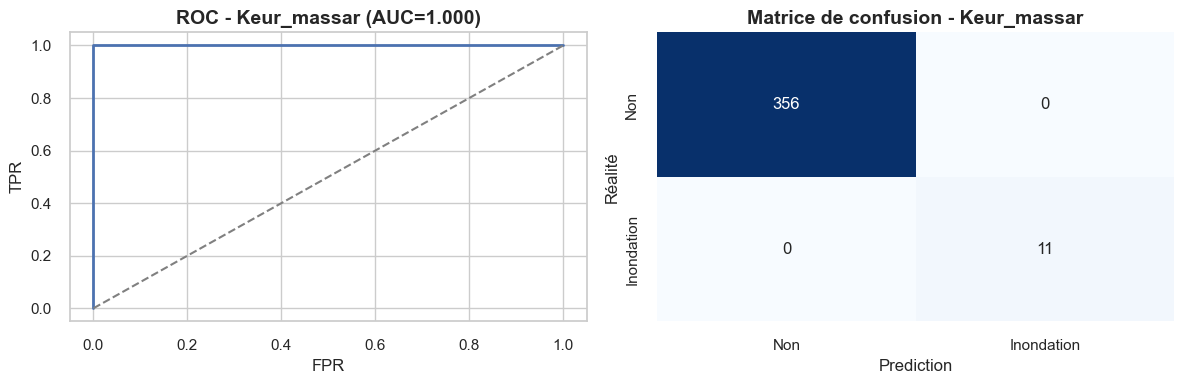

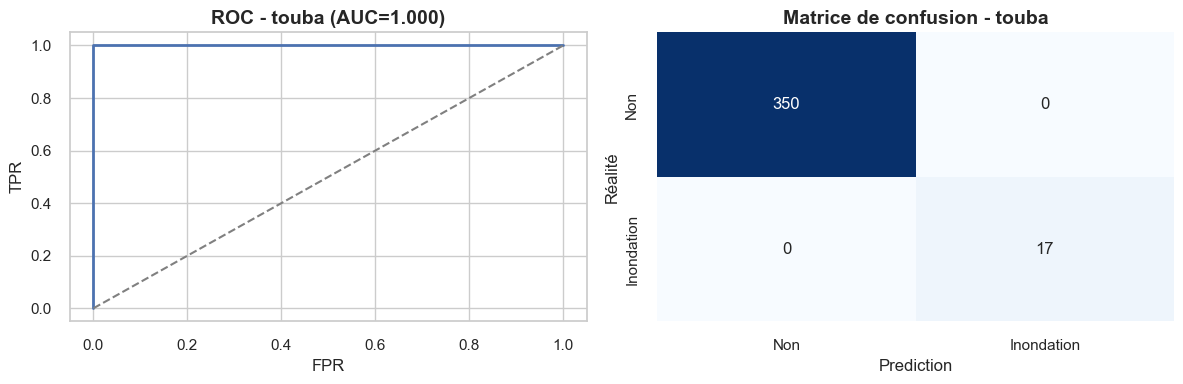

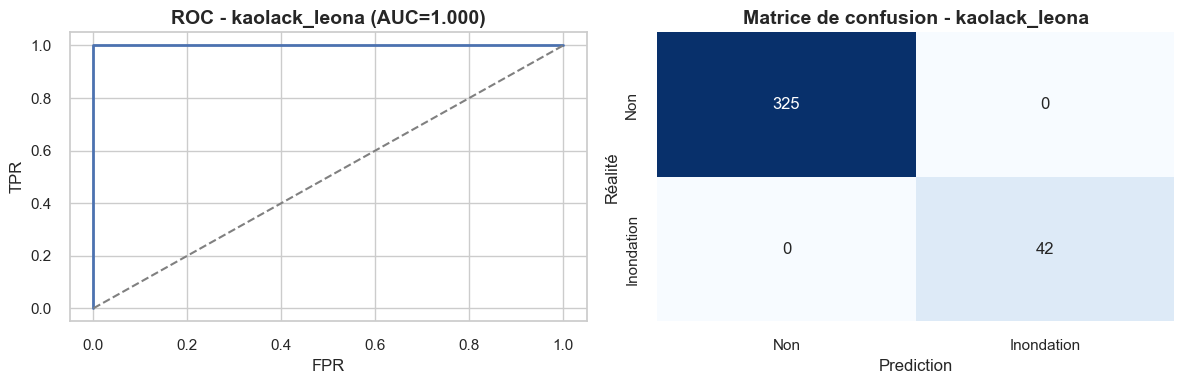

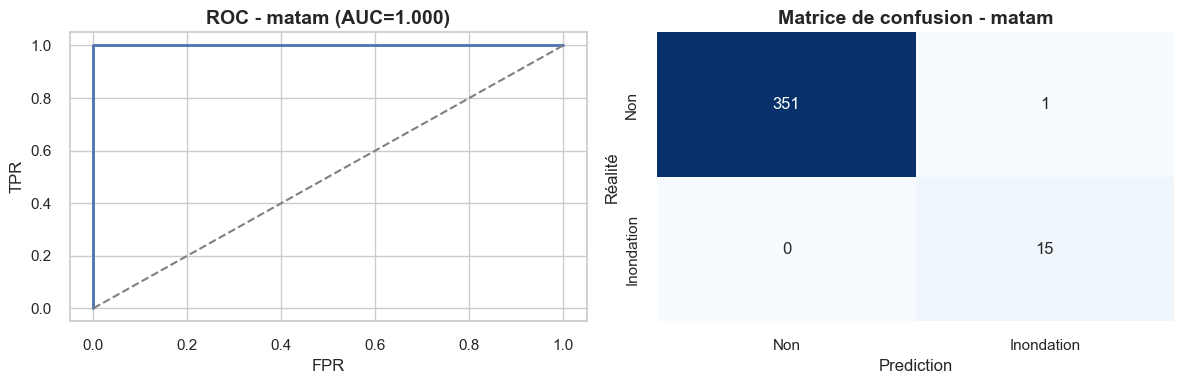

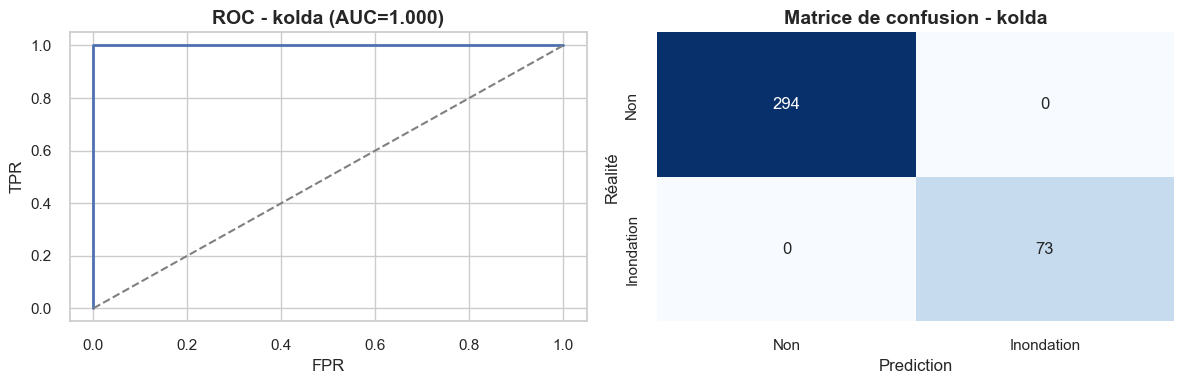

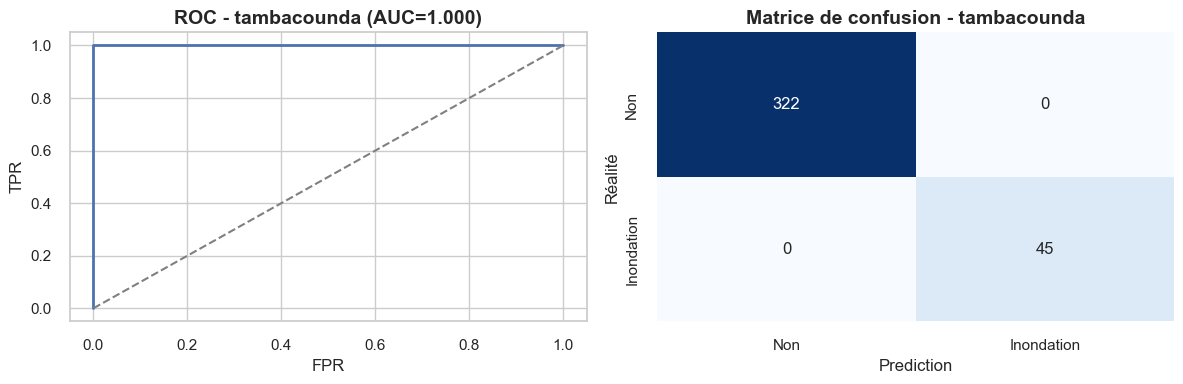

In [ ]:

zones = ['Keur_massar', 'touba', 'kaolack_leona', 'matam', 'kolda', 'tambacounda']

rows = []
for zone in zones:
    mask = test['location'].astype(str).str.casefold() == zone.casefold()
    dfz = test[mask].copy()
    if dfz.empty:
        rows.append({'zone': zone, 'support_pos': 0, 'support_total': 0,
                     'roc_auc': float('nan'), 'average_precision': float('nan'),
                     'precision': float('nan'), 'recall': float('nan'),
                     'f1': float('nan'), 'accuracy': float('nan')})
        continue

    Xz = scaler.transform(dfz[SELECTED_FEATURES].ffill().bfill().fillna(0).to_numpy(dtype=float))
    yz = dfz['flood_risk'].to_numpy(dtype=int)
    proba_z = rf.predict_proba(Xz)[:, 1]
    pred_z = (proba_z >= SEUIL_OPTIMAL).astype(int)

    has_both = len(np.unique(yz)) == 2
    roc = roc_auc_score(yz, proba_z) if has_both else float('nan')
    ap = average_precision_score(yz, proba_z) if has_both else float('nan')
    prec = precision_score(yz, pred_z, zero_division=0)
    rec = recall_score(yz, pred_z, zero_division=0)
    f1s = f1_score(yz, pred_z, zero_division=0)
    acc = accuracy_score(yz, pred_z)

    rows.append({
        'zone': zone,
        'support_pos': int(yz.sum()),
        'support_total': int(len(yz)),
        'roc_auc': roc,
        'average_precision': ap,
        'precision': prec,
        'recall': rec,
        'f1': f1s,
        'accuracy': acc,
    })

    # Plots: ROC + matrice de confusion
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    # ROC
    if has_both:
        fpr_z, tpr_z, _ = roc_curve(yz, proba_z)
        axes[0].plot(fpr_z, tpr_z, lw=2)
        axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray')
        axes[0].set_title(f'ROC - {zone} (AUC={roc:.3f})')
        axes[0].set_xlabel('FPR')
        axes[0].set_ylabel('TPR')
    else:
        axes[0].text(0.5, 0.5, 'Une seule classe présente', ha='center', va='center')
        axes[0].set_title(f'ROC - {zone}')
        axes[0].set_xticks([])
        axes[0].set_yticks([])

    # Confusion matrix
    cm = confusion_matrix(yz, pred_z)
    cm_df = pd.DataFrame(cm, index=['Non', 'Inondation'][:cm.shape[0]], columns=['Non', 'Inondation'][:cm.shape[1]])
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[1])
    axes[1].set_title(f'Matrice de confusion - {zone}')
    axes[1].set_xlabel('Prediction')
    axes[1].set_ylabel('Réalité')
    plt.tight_layout()
    plt.show()


# 16 Tableau récapitulatif

In [ ]:


zone_perf = pd.DataFrame(rows).set_index('zone')
zone_perf[['support_pos', 'support_total', 'roc_auc', 'average_precision', 'precision', 'recall', 'f1', 'accuracy']]

,support_pos,support_total,roc_auc,average_precision,precision,recall,f1,accuracy
zone,,,,,,,,
Keur_massar,11,367,1.0,1.0,1.0000,1.0,1.000000,1.000000
touba,17,367,1.0,1.0,1.0000,1.0,1.000000,1.000000
kaolack_leona,42,367,1.0,1.0,1.0000,1.0,1.000000,1.000000
matam,15,367,1.0,1.0,0.9375,1.0,0.967742,0.997275
kolda,73,367,1.0,1.0,1.0000,1.0,1.000000,1.000000
tambacounda,45,367,1.0,1.0,1.0000,1.0,1.000000,1.000000


## 17. Fonction de prédiction


In [1]:
def predict_risk(feature_vector: Iterable[float]) -> Dict[str, float]:
    vector = np.array(list(feature_vector), dtype=float).reshape(1, -1)
    scaled = scaler.transform(vector)
    proba = rf.predict_proba(scaled)[0, 1]
    return {'proba_inondation': float(proba), 'prediction': int(proba >= SEUIL_OPTIMAL)}

example_vector = test[SELECTED_FEATURES].iloc[0]
predict_risk(example_vector)

NameError: name 'Iterable' is not defined